In [1]:
#2.决策树练习并调参，从而提升准确率，随机森林练习，结合网格搜索调参，找到最佳参数模型,
#可以让AI帮忙调参，告诉AI你的数据集情况，然后让其帮你修改超参

import pandas as pd

df = pd.read_csv("data/titanic.csv", usecols=["pclass", "sex", "age", "survived"])

display(df.head())
print(df.isnull().sum())
print(df.describe(include="all"))

,pclass,survived,age,sex
0,1st,1,29.0000,female
1,1st,0,2.0000,female
2,1st,0,30.0000,male
3,1st,0,25.0000,female
4,1st,1,0.9167,male


pclass        0
survived      0
age         680
sex           0
dtype: int64
       pclass     survived         age   sex
count    1313  1313.000000  633.000000  1313
unique      3          NaN         NaN     2
top       3rd          NaN         NaN  male
freq      711          NaN         NaN   850
mean      NaN     0.341965   31.194181   NaN
std       NaN     0.474549   14.747525   NaN
min       NaN     0.000000    0.166700   NaN
25%       NaN     0.000000   21.000000   NaN
50%       NaN     0.000000   30.000000   NaN
75%       NaN     1.000000   41.000000   NaN
max       NaN     1.000000   71.000000   NaN


In [2]:
# 预处理
df['age'] = df['age'].fillna(df['age'].mean())
y = df['survived']

X = pd.get_dummies(df[['sex', 'pclass']])
X['age'] = df['age']

X


,sex_female,sex_male,pclass_1st,pclass_2nd,pclass_3rd,age
0,True,False,True,False,False,29.000000
1,True,False,True,False,False,2.000000
2,False,True,True,False,False,30.000000
3,True,False,True,False,False,25.000000
4,False,True,True,False,False,0.916700
...,...,...,...,...,...,...
1308,False,True,False,False,True,31.194181
1309,False,True,False,False,True,31.194181
1310,False,True,False,False,True,31.194181
1311,True,False,False,False,True,31.194181


0.8365019011406845
60
203
95
168
survived    0    1
sex               
female    126  245
male      570  109


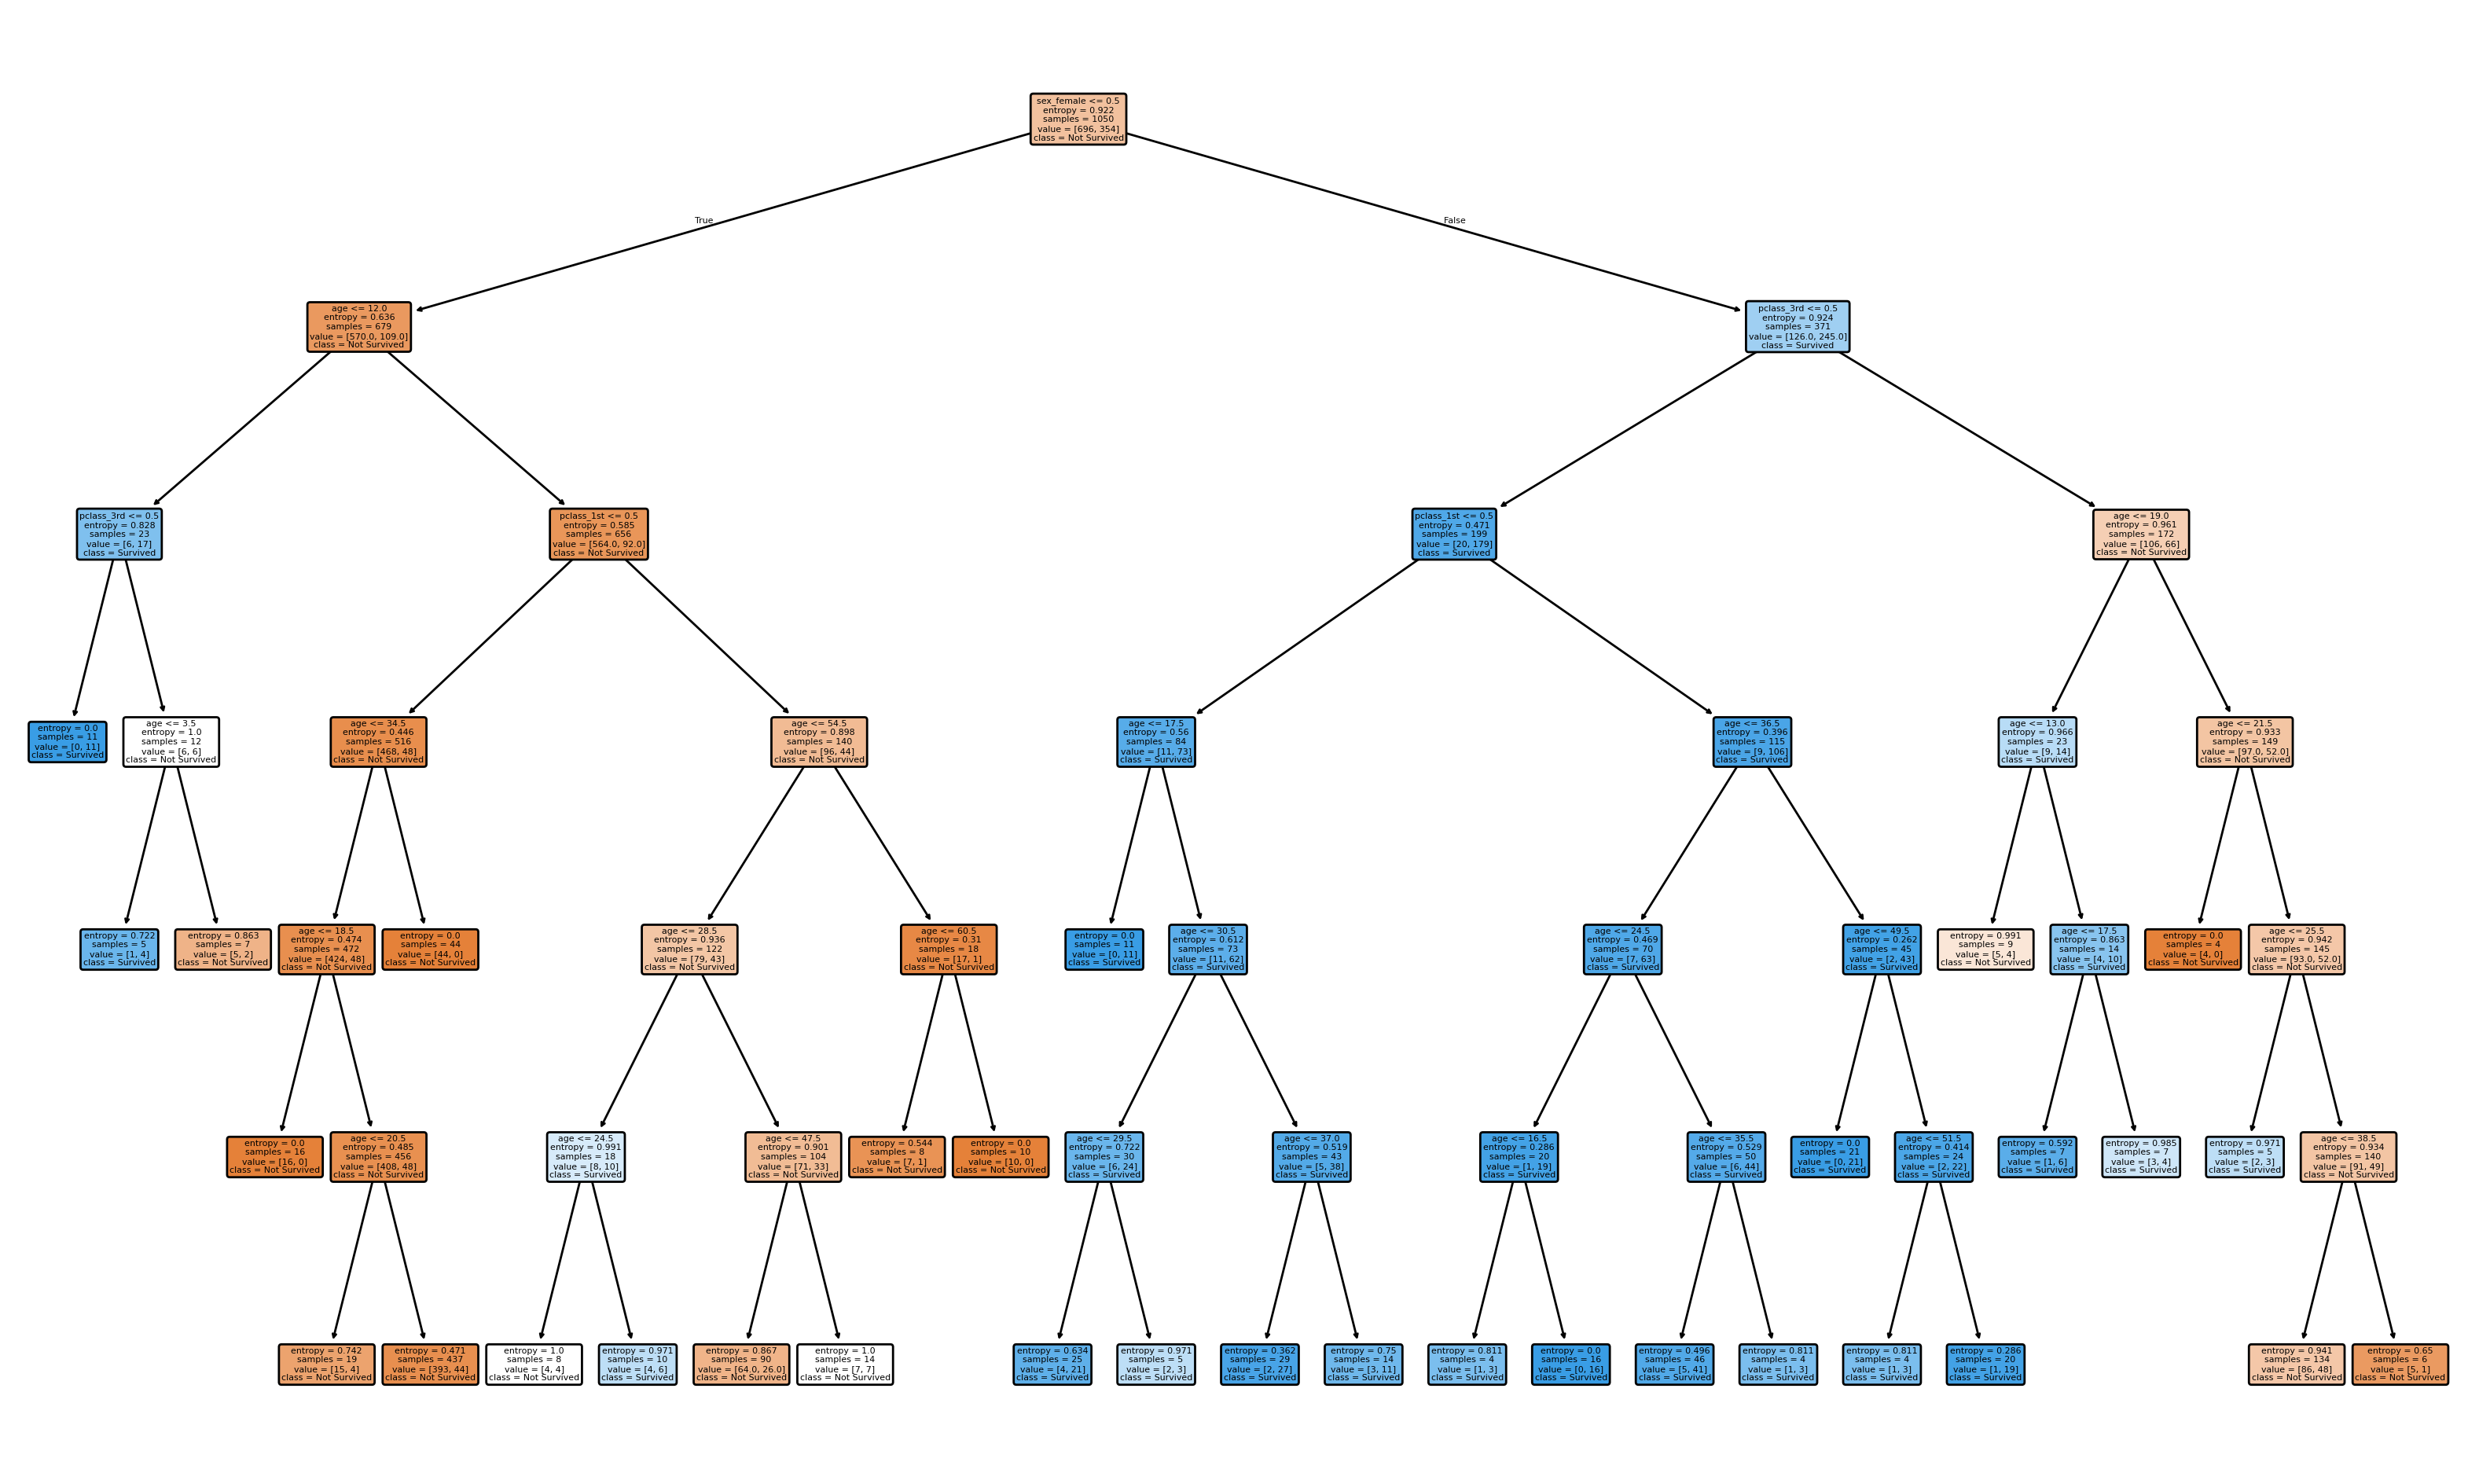

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import tree

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=None,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

plt.figure(figsize=(20, 12), dpi=200)
tree.plot_tree(clf, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True,rounded=True)
plt.savefig('tree.svg')

# 打印预测结果中各类别的数量
print((y_pred == 1).sum())  # 预测为1的数量
print((y_pred == 0).sum())  # 预测为0的数量
print((y_test == 1).sum())  # 真实标签中1的数量
print((y_test == 0).sum())  # 真实标签中0的数量

# 从原始数据中提取训练集对应的性别和生存标签
sex_train = df.loc[X_train.index, 'sex']  # 获取训练集的性别列
survived_train = y_train  # 训练集的生存标签

# 构造包含性别和生存信息的DataFrame
sex_survived = pd.DataFrame({
    'sex': sex_train,
    'survived': survived_train
})

# 按性别和生存情况分组统计数量，并重塑为透视表
grouped = sex_survived.groupby(['sex', 'survived']).size().unstack(fill_value=0)
print(grouped)  # 输出分组统计结果


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=5,

    criterion='entropy'
)
rf_clf.fit(X_train, y_train)

rf_y_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_y_pred)
print('my accuracy:',rf_acc)

my accuracy: 0.8403041825095057


In [25]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 500],      # 森林中树的数量，适度增加以提升稳定性
    'max_depth': [5, 7, None],              # 树的最大深度，保留 None 以允许充分生长
    'criterion': ['gini'],                  # 仅保留 gini，通常效果最佳
    'max_features': ['sqrt'],               # 每棵树最大特征数，sqrt 为经验最优
    'min_samples_split': [2, 5],            # 内部节点再划分所需最小样本数，减少过拟合
    'min_samples_leaf': [1, 2],             # 叶子节点最少样本数，保持简单
    'random_state': [42]                    # 保证可复现
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_max_features = grid_search.best_params_['max_features']
if best_max_features is None or best_max_features == 'auto':
    n_features_used = X_train.shape[1]
elif best_max_features == 'sqrt':
    import math
    n_features_used = int(math.sqrt(X_train.shape[1]))
elif best_max_features == 'log2':
    import math
    n_features_used = int(math.log2(X_train.shape[1]))
else:
    n_features_used = best_max_features
    
print(n_features_used)

best_rf = grid_search.best_estimator_
test_accuracy = best_rf.score(X_test, y_test)
print(test_accuracy)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300, 'random_state': 42}
0.8247619047619048
2
0.8326996197718631
